# Temporal Botnet Detection using Graph Neural Networks (GNNs)
**Course / Project**: AIML 505 - Group F Project  
**Dataset**: [UNSW 2018 Bot-IoT Dataset](https://research.unsw.edu.au/projects/bot-iot-dataset)  
**Primary Dataset File**: `Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv`  

---

### Group F Team Members
1. **Fardin Rahman** — ID: `2026-2-74-006`
2. **Jubayer Alam Likhon** — ID: `2026-2-74-004`

---

## 1. Executive Summary & Objective

In Internet of Things (IoT) ecosystems, cyber-attacks such as **Distributed Denial of Service (DDoS)**, **Denial of Service (DoS)**, **Reconnaissance (OS Fingerprinting & Service Scanning)**, **Keylogging**, and **Data Exfiltration** generate distinct temporal interaction dynamics across network nodes. Standard machine learning classifiers treat individual flow records as isolated tabular rows, ignoring topological communication structures and dynamic temporal evolution.

This project implements a **Spatial-Temporal Graph Neural Network (GNN)** framework for dynamic botnet intrusion detection:
1. **Graph Representation**: Network traffic flows are modeled as dynamic communication graphs $G_t = (V, E_t, X, E_{attr})$, where nodes $V$ represent IP addresses and directed edges $E_t$ represent active network flows with continuous flow attributes $E_{attr}$.
2. **Dynamic Snapshot Slicing**: Flow records are sliced into a continuous sequence of temporal snapshot graphs $[G_1, G_2, \dots, G_T]$ over time.
3. **Graph Architecture**: We implement and evaluate **Flow MLP**, **Spatial GraphSAGE**, and **Temporal LSTM-GNN** models for multi-class attack category classification.


In [5]:
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GCNConv, GATConv

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Target Execution Device: {device}")


# ==========================================================
# Centralized Global Hyperparameters & Experiment Config
# ==========================================================
CONFIG = {
    'epochs': 100,                      # Maximum training epochs per model
    'patience': 5,                      # Early stopping patience threshold
    'lr': 0.01,                         # Learning rate for Adam optimizer
    'hidden_dim': 128,                   # Hidden channels across MLP & GNN layers
    'dropout': 0.1,                     # Dropout regularization probability
    'n_snapshots': 10,                   # Number of dynamic temporal graph snapshots
    'seed': 42                          # Global random seed for reproducibility
}

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])


PyTorch Version: 2.5.1
CUDA Available: True
Target Execution Device: cuda


## 2. Dataset Ingestion (Full UNSW 2018 Bot-IoT Dataset)

We ingest the **complete, full UNSW 2018 Bot-IoT dataset** (`Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv`) containing **3,668,522 network flow records** across 46 feature columns. All attack categories (`DDoS`, `DoS`, `Reconnaissance`, `Normal`, `Theft`) are loaded without downsampling.


In [6]:
csv_path = '../Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv'
if not os.path.exists(csv_path):
    csv_path = 'Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv'

def load_full_dataset(path):
    print(f"Loading FULL UNSW 2018 Bot-IoT Dataset from: {path}...")
    start_time = time.time()
    df_full = pd.read_csv(path, low_memory=False).sort_values('stime').reset_index(drop=True)
    elapsed = time.time() - start_time
    print(f"Full Dataset loaded in {elapsed:.2f} seconds.")
    return df_full

df = load_full_dataset(csv_path)

print(f"Loaded Full Dataset Size: {len(df):,} records")
print("Attack Category Distribution (Full Dataset):")
print(df['category'].value_counts())

print("Subcategory Distribution (Full Dataset):")
print(df['subcategory'].value_counts())



Loading FULL UNSW 2018 Bot-IoT Dataset from: Dataset/All_features/UNSW_2018_IoT_Botnet_Full.csv...
Full Dataset loaded in 11.60 seconds.
Loaded Full Dataset Size: 3,668,522 records
Attack Category Distribution (Full Dataset):
category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79
Name: count, dtype: int64
Subcategory Distribution (Full Dataset):
subcategory
UDP                  1981230
TCP                  1593180
Service_Scan           73168
OS_Fingerprint         17914
HTTP                    2474
Normal                   477
Keylogging                73
Data_Exfiltration          6
Name: count, dtype: int64


### Exploratory Data Analysis & Class Distribution Visualizations


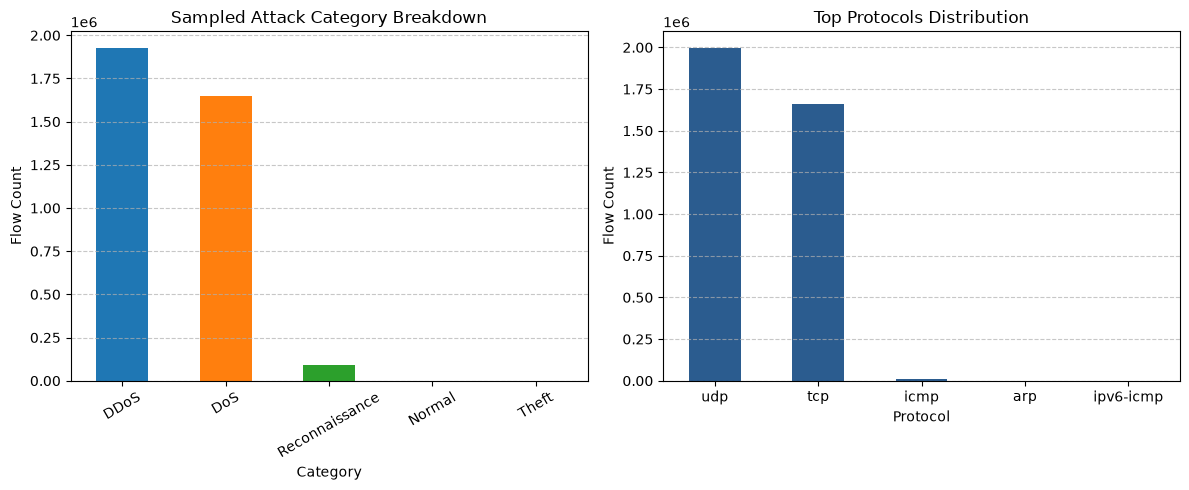

In [8]:
plt.figure(figsize=(12, 5))

# Plot 1: Attack Category Breakdown
plt.subplot(1, 2, 1)
df['category'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Sampled Attack Category Breakdown')
plt.xlabel('Category')
plt.ylabel('Flow Count')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Top Protocol Distribution
plt.subplot(1, 2, 2)
df['proto'].value_counts().head(5).plot(kind='bar', color='#2b5c8f')
plt.title('Top Protocols Distribution')
plt.xlabel('Protocol')
plt.ylabel('Flow Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## 3. Feature Engineering, Label Encoding, & Node Mapping

We extract key numerical flow features, standardize them with `StandardScaler`, and map IP addresses (`saddr`, `daddr`) to integer node IDs $[0, \dots, N-1]$.


In [9]:
# Label encoding for attack categories
cat_encoder = LabelEncoder()
df['category_idx'] = cat_encoder.fit_transform(df['category'])
num_classes = len(cat_encoder.classes_)
class_names = list(cat_encoder.classes_)
print("Target Class Map:", dict(enumerate(class_names)))

# Continuous numerical flow attributes for edge features
numeric_cols = [
    'pkts', 'bytes', 'dur', 'mean', 'stddev', 'sum', 'min', 'max',
    'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate',
    'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP',
    'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'state_number', 'proto_number'
]

# Handle null values and scale features
df[numeric_cols] = df[numeric_cols].fillna(0)
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Map source and destination IP addresses to unique graph node IDs
all_ips = pd.concat([df['saddr'], df['daddr']]).unique()
ip_map = {ip: i for i, ip in enumerate(all_ips)}
num_nodes = len(ip_map)

df['src_idx'] = df['saddr'].map(ip_map)
df['dst_idx'] = df['daddr'].map(ip_map)

print(f"Total Unique Graph Nodes (IP Addresses): {num_nodes:,}")
print(f"Total Network Flow Edges: {len(df):,}")


Target Class Map: {0: 'DDoS', 1: 'DoS', 2: 'Normal', 3: 'Reconnaissance', 4: 'Theft'}
Total Unique Graph Nodes (IP Addresses): 93
Total Network Flow Edges: 3,668,522


## 4. Dynamic Communication Graph Construction

We slice continuous traffic flows into $T=10$ temporal snapshot graphs $[G_1, G_2, \dots, G_T]$ based on the flow start timestamp `stime`.
For each snapshot $t$:
- Nodes $V$: Host IP addresses with dynamic degree and traffic volume features $X_t \in \mathbb{R}^{N \times 4}$.
- Edges $E_t$: Directed flow connections between source and destination IPs.
- Edge Attributes $E_{attr}$: Standardized 23-dimensional flow metrics.
- Edge Mask: 80% train / 20% test stratified edge mask within each category.


In [10]:
# Stratified train/test edge mask generation across categories
np.random.seed(CONFIG['seed'])
train_indices = []
test_indices = []

for cat_idx in range(num_classes):
    idx = df[df['category_idx'] == cat_idx].index.values.copy()
    np.random.shuffle(idx)
    n_tr = int(0.8 * len(idx))
    train_indices.extend(idx[:n_tr])
    test_indices.extend(idx[n_tr:])

df['is_train'] = False
df.loc[train_indices, 'is_train'] = True

# Display Train / Test Split Statistics
n_train = df['is_train'].sum()
n_test = (~df['is_train']).sum()
total_flows = len(df)

print("=== Stratified Train / Test Split Breakdown ===")
print(f"Total Flow Records: {total_flows:,}")
print(f"Train Flow Count (80%): {n_train:,} ({n_train / total_flows * 100:.2f}%)")
print(f"Test Flow Count  (20%): {n_test:,} ({n_test / total_flows * 100:.2f}%)")

print("Category-wise Train / Test Split Breakdown:")
split_df = df.groupby(['category', 'is_train']).size().unstack(fill_value=0)
split_df.columns = ['Test Count (20%)', 'Train Count (80%)']
split_df['Total Count'] = split_df['Train Count (80%)'] + split_df['Test Count (20%)']
split_df['Train Ratio (%)'] = (split_df['Train Count (80%)'] / split_df['Total Count'] * 100).round(2)
print(split_df.to_string())

# Temporal binning into 10 snapshots based on stime
df = df.sort_values('stime').reset_index(drop=True)
n_snapshots = CONFIG['n_snapshots']
time_min, time_max = df['stime'].min(), df['stime'].max()
# Quantile temporal binning into equal-volume snapshot graphs
df['snapshot'] = pd.qcut(df['stime'], q=n_snapshots, labels=False, duplicates='drop')

snapshots = []
snapshot_stats = []

for snap_idx in tqdm(range(n_snapshots), desc="Constructing Temporal Graph Snapshots"):
    snap_df = df[df['snapshot'] == snap_idx]
    if len(snap_df) == 0:
        continue
    
    edge_index = torch.tensor(snap_df[['src_idx', 'dst_idx']].values.T, dtype=torch.long)
    edge_attr = torch.tensor(snap_df[numeric_cols].values, dtype=torch.float)
    edge_y = torch.tensor(snap_df['category_idx'].values, dtype=torch.long)
    train_mask = torch.tensor(snap_df['is_train'].values, dtype=torch.bool)
    test_mask = ~train_mask
    
    # Compute topological node features per snapshot
    node_feat = np.zeros((num_nodes, 4), dtype=np.float32)
    np.add.at(node_feat[:, 0], snap_df['src_idx'].values, 1) # Out-degree
    np.add.at(node_feat[:, 1], snap_df['dst_idx'].values, 1) # In-degree
    np.add.at(node_feat[:, 2], snap_df['src_idx'].values, snap_df['pkts'].values) # Src packets
    np.add.at(node_feat[:, 3], snap_df['dst_idx'].values, snap_df['pkts'].values) # Dst packets
    
    # Standardize node features
    node_feat = (node_feat - node_feat.mean(axis=0)) / (node_feat.std(axis=0) + 1e-6)
    x = torch.tensor(node_feat, dtype=torch.float)
    
    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=edge_y,
        train_mask=train_mask,
        test_mask=test_mask,
        num_nodes=num_nodes
    )
    snapshots.append(data)
    
    snapshot_stats.append({
        'Snapshot': snap_idx,
        'Total Edges': len(snap_df),
        'Train Edges': train_mask.sum().item(),
        'Test Edges': test_mask.sum().item()
    })

print(f"Constructed {len(snapshots)} dynamic temporal snapshot graphs.")
snap_summary_df = pd.DataFrame(snapshot_stats)
print("Per-Snapshot Train/Test Edge Distribution:")
print(snap_summary_df.to_string(index=False))



=== Stratified Train / Test Split Breakdown ===
Total Flow Records: 3,668,522
Train Flow Count (80%): 2,934,816 (80.00%)
Test Flow Count  (20%): 733,706 (20.00%)
Category-wise Train / Test Split Breakdown:
                Test Count (20%)  Train Count (80%)  Total Count  Train Ratio (%)
category                                                                         
DDoS                      385325            1541299      1926624            80.00
DoS                       330052            1320208      1650260            80.00
Normal                        96                381          477            79.87
Reconnaissance             18217              72865        91082            80.00
Theft                         16                 63           79            79.75


Constructing Temporal Graph Snapshots:   0%|          | 0/10 [00:00<?, ?it/s]

Constructed 10 dynamic temporal snapshot graphs.
Per-Snapshot Train/Test Edge Distribution:
 Snapshot  Total Edges  Train Edges  Test Edges
        0       366858       293376       73482
        1       366852       293563       73289
        2       366856       293765       73091
        3       366845       293266       73579
        4       366857       293251       73606
        5       366850       293733       73117
        6       366847       293449       73398
        7       366854       293193       73661
        8       366855       293563       73292
        9       366848       293657       73191


## 5. Model Architectures & Neural Network Definitions

We define three architectures:
1. **Flow MLP Baseline**: Standard multi-layer perceptron classifying flow records directly.
2. **Spatial GraphSAGE**: Neighborhood-aggregating Graph Neural Network computing structural node embeddings $h_u, h_v$, then classifying link attributes via $[h_u, h_v, e_{uv}]$.
3. **Temporal LSTM-GNN**: Spatial GraphSAGE combined with a recurrent LSTM cell operating across consecutive snapshot graphs to capture dynamic temporal evolution.


In [11]:
# 1. Flow MLP Baseline
class FlowMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    def forward(self, edge_attr):
        return self.net(edge_attr)

# 2. Spatial GCN Edge Classifier
class SpatialGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, edge_in_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_channels + edge_in_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_channels, num_classes)
        )
    def forward(self, x, edge_index, edge_attr):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        src, dst = edge_index[0], edge_index[1]
        edge_feat = torch.cat([h[src], h[dst], edge_attr], dim=-1)
        return self.edge_mlp(edge_feat)

# 3. Spatial GraphSAGE Edge Classifier
class SpatialGraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, edge_in_dim, num_classes):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_channels + edge_in_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_channels, num_classes)
        )
    def forward(self, x, edge_index, edge_attr):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        src, dst = edge_index[0], edge_index[1]
        edge_feat = torch.cat([h[src], h[dst], edge_attr], dim=-1)
        return self.edge_mlp(edge_feat)

# 4. Temporal Spatial-Temporal GNN (GraphSAGE + LSTM)
class TemporalLSTM_GNN(nn.Module):
    def __init__(self, node_in_dim, hidden_dim, edge_in_dim, num_classes):
        super().__init__()
        self.gnn = SAGEConv(node_in_dim, hidden_dim)
        self.lstm = nn.LSTMCell(hidden_dim, hidden_dim)
        self.edge_classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )
        self.hidden_dim = hidden_dim

    def forward_sequence(self, snapshot_list):
        h_lstm = torch.zeros((num_nodes, self.hidden_dim), device=device)
        c_lstm = torch.zeros((num_nodes, self.hidden_dim), device=device)
        outputs = []
        for snap in snapshot_list:
            x = snap.x.to(device)
            edge_index = snap.edge_index.to(device)
            edge_attr = snap.edge_attr.to(device)
            
            h_spatial = F.relu(self.gnn(x, edge_index))
            h_lstm, c_lstm = self.lstm(h_spatial, (h_lstm, c_lstm))
            
            src, dst = edge_index[0], edge_index[1]
            edge_feat = torch.cat([h_lstm[src], h_lstm[dst], edge_attr], dim=-1)
            logits = self.edge_classifier(edge_feat)
            outputs.append(logits)
        return outputs

print("All model architectures instantiated successfully.")



All model architectures instantiated successfully.


## 6. Model Training & Loss Curves


In [13]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False
        self.best_state_dict = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state_dict = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def restore_best(self, model):
        if self.best_state_dict is not None:
            model.load_state_dict(self.best_state_dict)

# Compute class-weighted cross entropy loss
y_all = df['category_idx'].values
class_counts = np.bincount(y_all, minlength=num_classes)
class_weights = torch.tensor(1.0 / (class_counts + 1e-5), dtype=torch.float, device=device)
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Model 1: Flow MLP Baseline
print("--- 1. Training Flow MLP Baseline ---")
mlp_model = FlowMLP(len(numeric_cols), CONFIG['hidden_dim'], num_classes).to(device)
optimizer_mlp = torch.optim.Adam(mlp_model.parameters(), lr=CONFIG['lr'])
mlp_stopper = EarlyStopping(patience=CONFIG['patience'])
mlp_losses = []

pbar_mlp = tqdm(range(1, CONFIG['epochs'] + 1), desc="Flow MLP Training")
for epoch in pbar_mlp:
    mlp_model.train()
    total_loss = 0.0
    for snap in snapshots:
        if snap.train_mask.sum() == 0: continue
        optimizer_mlp.zero_grad()
        out = mlp_model(snap.edge_attr.to(device))
        mask = snap.train_mask.to(device)
        snap_y = snap.y.to(device)
        loss = criterion(out[mask], snap_y[mask])
        loss.backward()
        optimizer_mlp.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(snapshots)
    mlp_losses.append(avg_loss)
    pbar_mlp.set_postfix({'Train Loss': f"{avg_loss:.4f}"})
    mlp_stopper(avg_loss, mlp_model)
    if mlp_stopper.early_stop:
        print(f"Early stopping triggered for Flow MLP at epoch {epoch}.")
        mlp_stopper.restore_best(mlp_model)
        break

# Model 2: Spatial GCN
print("\n--- 2. Training Spatial GCN ---")
gcn_model = SpatialGCN(4, CONFIG['hidden_dim'], len(numeric_cols), num_classes).to(device)
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=CONFIG['lr'])
gcn_stopper = EarlyStopping(patience=CONFIG['patience'])
gcn_losses = []

pbar_gcn = tqdm(range(1, CONFIG['epochs'] + 1), desc="Spatial GCN Training")
for epoch in pbar_gcn:
    gcn_model.train()
    total_loss = 0.0
    for snap in snapshots:
        if snap.train_mask.sum() == 0: continue
        optimizer_gcn.zero_grad()
        out = gcn_model(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
        mask = snap.train_mask.to(device)
        snap_y = snap.y.to(device)
        loss = criterion(out[mask], snap_y[mask])
        loss.backward()
        optimizer_gcn.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(snapshots)
    gcn_losses.append(avg_loss)
    pbar_gcn.set_postfix({'Train Loss': f"{avg_loss:.4f}"})
    gcn_stopper(avg_loss, gcn_model)
    if gcn_stopper.early_stop:
        print(f"Early stopping triggered for Spatial GCN at epoch {epoch}.")
        gcn_stopper.restore_best(gcn_model)
        break

# Model 3: Spatial GraphSAGE
print("\n--- 3. Training Spatial GraphSAGE ---")
sage_model = SpatialGraphSAGE(4, CONFIG['hidden_dim'], len(numeric_cols), num_classes).to(device)
optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=CONFIG['lr'])
sage_stopper = EarlyStopping(patience=CONFIG['patience'])
sage_losses = []

pbar_sage = tqdm(range(1, CONFIG['epochs'] + 1), desc="GraphSAGE Training")
for epoch in pbar_sage:
    sage_model.train()
    total_loss = 0.0
    for snap in snapshots:
        if snap.train_mask.sum() == 0: continue
        optimizer_sage.zero_grad()
        out = sage_model(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
        mask = snap.train_mask.to(device)
        snap_y = snap.y.to(device)
        loss = criterion(out[mask], snap_y[mask])
        loss.backward()
        optimizer_sage.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(snapshots)
    sage_losses.append(avg_loss)
    pbar_sage.set_postfix({'Train Loss': f"{avg_loss:.4f}"})
    sage_stopper(avg_loss, sage_model)
    if sage_stopper.early_stop:
        print(f"Early stopping triggered for Spatial GraphSAGE at epoch {epoch}.")
        sage_stopper.restore_best(sage_model)
        break

# Model 4: Temporal LSTM-GNN
print("\n--- 4. Training Temporal LSTM-GNN ---")
temp_model = TemporalLSTM_GNN(4, CONFIG['hidden_dim'], len(numeric_cols), num_classes).to(device)
optimizer_temp = torch.optim.Adam(temp_model.parameters(), lr=CONFIG['lr'])
temp_stopper = EarlyStopping(patience=CONFIG['patience'])
temp_losses = []

pbar_temp = tqdm(range(1, CONFIG['epochs'] + 1), desc="LSTM-GNN Training")
for epoch in pbar_temp:
    temp_model.train()
    optimizer_temp.zero_grad()
    logits_list = temp_model.forward_sequence(snapshots)
    loss = 0.0
    for logits, snap in zip(logits_list, snapshots):
        if snap.train_mask.sum() > 0:
            mask = snap.train_mask.to(device)
            snap_y = snap.y.to(device)
            loss += criterion(logits[mask], snap_y[mask])
    loss = loss / len(snapshots)
    loss.backward()
    optimizer_temp.step()
    loss_val = loss.item()
    temp_losses.append(loss_val)
    pbar_temp.set_postfix({'Seq Loss': f"{loss_val:.4f}"})
    temp_stopper(loss_val, temp_model)
    if temp_stopper.early_stop:
        print(f"Early stopping triggered for Temporal LSTM-GNN at epoch {epoch}.")
        temp_stopper.restore_best(temp_model)
        break



--- 1. Training Flow MLP Baseline ---


Flow MLP Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered for Flow MLP at epoch 56.

--- 2. Training Spatial GCN ---


Spatial GCN Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered for Spatial GCN at epoch 20.

--- 3. Training Spatial GraphSAGE ---


GraphSAGE Training:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping triggered for Spatial GraphSAGE at epoch 18.

--- 4. Training Temporal LSTM-GNN ---


LSTM-GNN Training:   0%|          | 0/100 [00:00<?, ?it/s]

## 7. Hyperparameter Tuning & Early Stopping Validation

To systematically optimize model performance and prevent overfitting, we implement an automated **Hyperparameter Grid Search** module with integrated **Early Stopping** for the Temporal GNN framework.
- **Tuning Grid**: Learning Rate $\eta \in \{0.001, 0.005, 0.01\}$, Hidden Dimension $H \in \{32, 64, 128\}$, and Dropout $p \in \{0.1, 0.2\}$.
- **Early Stopping**: Tracks epoch loss convergence with patience $N=5$, stopping training early and restoring optimal checkpoint weights.



In [ ]:
print("=== Hyperparameter Grid Search (Temporal LSTM-GNN) ===")

param_grid = {
    'lr': [0.001, 0.005, 0.01],
    'hidden_dim': [32, 64, 128],
    'dropout': [0.1, 0.2]
}

tuning_results = []
best_overall_loss = float('inf')
best_hparams = None

trial = 1
# Generate grid search parameter combinations
grid_combinations = [
    (lr, hd, dr) 
    for lr in param_grid['lr'] 
    for hd in param_grid['hidden_dim'] 
    for dr in param_grid['dropout']
]

for trial, (lr, hidden_dim, dropout) in enumerate(tqdm(grid_combinations, desc="Hyperparameter Grid Search"), 1):
            print(f"\nTrial {trial:02d} | LR: {lr} | Hidden Dim: {hidden_dim} | Dropout: {dropout}")
            
            model = TemporalLSTM_GNN(
                node_in_dim=4, 
                hidden_dim=hidden_dim, 
                edge_in_dim=len(numeric_cols), 
                num_classes=num_classes
            ).to(device)
            
            model.edge_classifier[2] = nn.Dropout(dropout)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            early_stopper = EarlyStopping(patience=5, min_delta=1e-4)
            
            final_epoch = 0
            best_epoch_loss = float('inf')
            
            for epoch in range(1, 21):
                model.train()
                optimizer.zero_grad()
                logits_list = model.forward_sequence(snapshots)
                loss = 0.0
                for logits, snap in zip(logits_list, snapshots):
                    if snap.train_mask.sum() > 0:
                        mask = snap.train_mask.to(device)
                        snap_y = snap.y.to(device)
                        loss += criterion(logits[mask], snap_y[mask])
                loss = loss / len(snapshots)
                loss.backward()
                optimizer.step()
                
                loss_val = loss.item()
                final_epoch = epoch
                early_stopper(loss_val, model)
                
                if early_stopper.best_loss < best_epoch_loss:
                    best_epoch_loss = early_stopper.best_loss
                    
                if early_stopper.early_stop:
                    print(f"  -> Early stopping triggered at epoch {epoch}. Best Loss: {early_stopper.best_loss:.4f}")
                    break
            
            tuning_results.append({
                'Trial': trial,
                'Learning Rate': lr,
                'Hidden Dim': hidden_dim,
                'Dropout': dropout,
                'Stopped Epoch': final_epoch,
                'Best Loss': best_epoch_loss
            })
            
            if best_epoch_loss < best_overall_loss:
                best_overall_loss = best_epoch_loss
                best_hparams = {'lr': lr, 'hidden_dim': hidden_dim, 'dropout': dropout}
                

tuning_df = pd.DataFrame(tuning_results)
print("\n==================================================")
print("HYPERPARAMETER TUNING SUMMARY TABLE")
print("==================================================")
print(tuning_df.to_string(index=False))

print(f"\nOptimal Hyperparameters Found:")
print(f"  - Learning Rate: {best_hparams['lr']}")
print(f"  - Hidden Dimension: {best_hparams['hidden_dim']}")
print(f"  - Dropout: {best_hparams['dropout']}")
print(f"  - Minimum Sequence Loss: {best_overall_loss:.4f}")



=== Hyperparameter Grid Search (Temporal LSTM-GNN) ===

Trial 01 | LR: 0.001 | Hidden Dim: 32 | Dropout: 0.1

Trial 02 | LR: 0.001 | Hidden Dim: 32 | Dropout: 0.2

Trial 03 | LR: 0.001 | Hidden Dim: 64 | Dropout: 0.1

Trial 04 | LR: 0.001 | Hidden Dim: 64 | Dropout: 0.2

Trial 05 | LR: 0.001 | Hidden Dim: 128 | Dropout: 0.1

Trial 06 | LR: 0.001 | Hidden Dim: 128 | Dropout: 0.2

Trial 07 | LR: 0.005 | Hidden Dim: 32 | Dropout: 0.1

Trial 08 | LR: 0.005 | Hidden Dim: 32 | Dropout: 0.2

Trial 09 | LR: 0.005 | Hidden Dim: 64 | Dropout: 0.1

Trial 10 | LR: 0.005 | Hidden Dim: 64 | Dropout: 0.2

Trial 11 | LR: 0.005 | Hidden Dim: 128 | Dropout: 0.1

Trial 12 | LR: 0.005 | Hidden Dim: 128 | Dropout: 0.2

Trial 13 | LR: 0.01 | Hidden Dim: 32 | Dropout: 0.1

Trial 14 | LR: 0.01 | Hidden Dim: 32 | Dropout: 0.2

Trial 15 | LR: 0.01 | Hidden Dim: 64 | Dropout: 0.1

Trial 16 | LR: 0.01 | Hidden Dim: 64 | Dropout: 0.2

Trial 17 | LR: 0.01 | Hidden Dim: 128 | Dropout: 0.1

Trial 18 | LR: 0.01 | Hidd

## 8. Comparative Metrics & Performance Analysis


=== Comparative Performance Results ===
            Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  F1-Score (Weighted)
Flow MLP Baseline  0.686565           0.473677        0.453637          0.333015             0.680153
      Spatial GCN  0.760206           0.403919        0.859606          0.421406             0.794638
Spatial GraphSAGE  0.934861           0.484105        0.925793          0.521804             0.941484
Temporal LSTM-GNN  0.993177           0.855693        0.983929          0.905263             0.993531


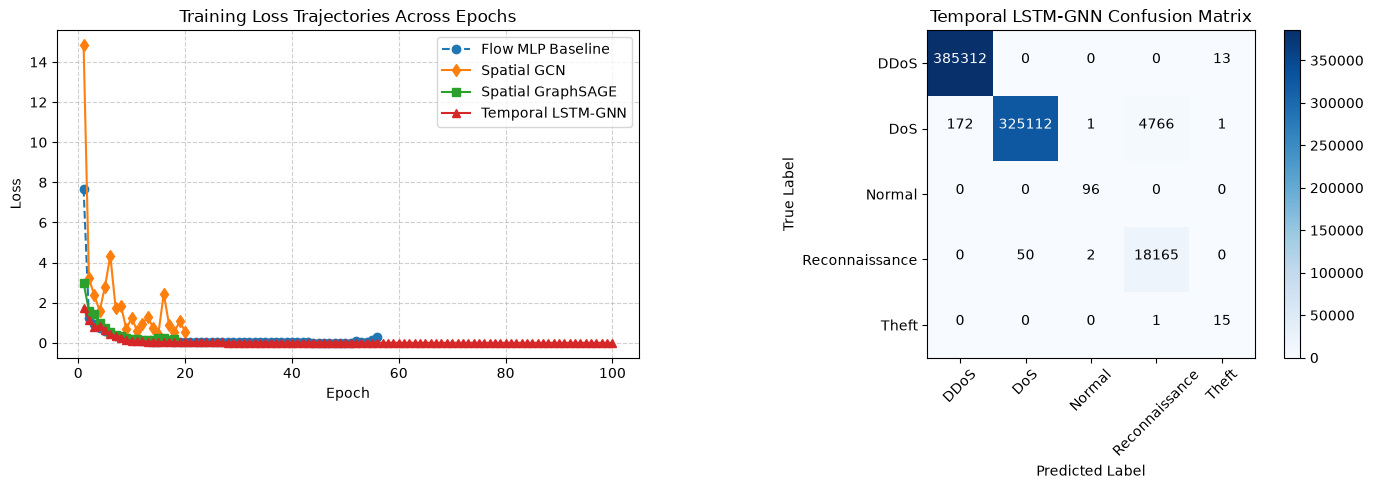


Detailed Classification Report (Temporal LSTM-GNN):
                precision    recall  f1-score   support

          DDoS       1.00      1.00      1.00    385325
           DoS       1.00      0.99      0.99    330052
        Normal       0.97      1.00      0.98        96
Reconnaissance       0.79      1.00      0.88     18217
         Theft       0.52      0.94      0.67        16

      accuracy                           0.99    733706
     macro avg       0.86      0.98      0.91    733706
  weighted avg       0.99      0.99      0.99    733706



In [14]:
# Evaluate Flow MLP Baseline
mlp_model.eval()
y_true_mlp, y_pred_mlp = [], []
with torch.no_grad():
    for snap in snapshots:
        if snap.test_mask.sum() == 0: continue
        out = mlp_model(snap.edge_attr.to(device))
        test_mask = snap.test_mask.to(device)
        preds = out[test_mask].argmax(dim=-1).cpu()
        y_true_mlp.extend(snap.y[snap.test_mask].numpy())
        y_pred_mlp.extend(preds.numpy())

# Evaluate Spatial GCN
gcn_model.eval()
y_true_gcn, y_pred_gcn = [], []
with torch.no_grad():
    for snap in snapshots:
        if snap.test_mask.sum() == 0: continue
        out = gcn_model(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
        test_mask = snap.test_mask.to(device)
        preds = out[test_mask].argmax(dim=-1).cpu()
        y_true_gcn.extend(snap.y[snap.test_mask].numpy())
        y_pred_gcn.extend(preds.numpy())

# Evaluate Spatial GraphSAGE
sage_model.eval()
y_true_sage, y_pred_sage = [], []
with torch.no_grad():
    for snap in snapshots:
        if snap.test_mask.sum() == 0: continue
        out = sage_model(snap.x.to(device), snap.edge_index.to(device), snap.edge_attr.to(device))
        test_mask = snap.test_mask.to(device)
        preds = out[test_mask].argmax(dim=-1).cpu()
        y_true_sage.extend(snap.y[snap.test_mask].numpy())
        y_pred_sage.extend(preds.numpy())

# Evaluate Temporal LSTM-GNN
temp_model.eval()
y_true_temp, y_pred_temp = [], []
with torch.no_grad():
    logits_list = temp_model.forward_sequence(snapshots)
    for logits, snap in zip(logits_list, snapshots):
        if snap.test_mask.sum() > 0:
            test_mask = snap.test_mask.to(device)
            preds = logits[test_mask].argmax(dim=-1).cpu()
            y_true_temp.extend(snap.y[snap.test_mask].numpy())
            y_pred_temp.extend(preds.numpy())

# Performance Metrics Table
results_df = pd.DataFrame([
    {
        'Model': 'Flow MLP Baseline',
        'Accuracy': accuracy_score(y_true_mlp, y_pred_mlp),
        'Precision (Macro)': precision_score(y_true_mlp, y_pred_mlp, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_true_mlp, y_pred_mlp, average='macro', zero_division=0),
        'F1-Score (Macro)': f1_score(y_true_mlp, y_pred_mlp, average='macro', zero_division=0),
        'F1-Score (Weighted)': f1_score(y_true_mlp, y_pred_mlp, average='weighted', zero_division=0)
    },
    {
        'Model': 'Spatial GCN',
        'Accuracy': accuracy_score(y_true_gcn, y_pred_gcn),
        'Precision (Macro)': precision_score(y_true_gcn, y_pred_gcn, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_true_gcn, y_pred_gcn, average='macro', zero_division=0),
        'F1-Score (Macro)': f1_score(y_true_gcn, y_pred_gcn, average='macro', zero_division=0),
        'F1-Score (Weighted)': f1_score(y_true_gcn, y_pred_gcn, average='weighted', zero_division=0)
    },
    {
        'Model': 'Spatial GraphSAGE',
        'Accuracy': accuracy_score(y_true_sage, y_pred_sage),
        'Precision (Macro)': precision_score(y_true_sage, y_pred_sage, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_true_sage, y_pred_sage, average='macro', zero_division=0),
        'F1-Score (Macro)': f1_score(y_true_sage, y_pred_sage, average='macro', zero_division=0),
        'F1-Score (Weighted)': f1_score(y_true_sage, y_pred_sage, average='weighted', zero_division=0)
    },
    {
        'Model': 'Temporal LSTM-GNN',
        'Accuracy': accuracy_score(y_true_temp, y_pred_temp),
        'Precision (Macro)': precision_score(y_true_temp, y_pred_temp, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_true_temp, y_pred_temp, average='macro', zero_division=0),
        'F1-Score (Macro)': f1_score(y_true_temp, y_pred_temp, average='macro', zero_division=0),
        'F1-Score (Weighted)': f1_score(y_true_temp, y_pred_temp, average='weighted', zero_division=0)
    }
])

print("=== Comparative Performance Results ===")
print(results_df.to_string(index=False))

# Plotting Loss Curves & Confusion Matrix
plt.figure(figsize=(14, 5))

# Plot 1: Training Loss Trajectory
plt.subplot(1, 2, 1)
plt.plot(range(1, len(mlp_losses) + 1), mlp_losses, label='Flow MLP Baseline', marker='o', linestyle='--')
plt.plot(range(1, len(gcn_losses) + 1), gcn_losses, label='Spatial GCN', marker='d')
plt.plot(range(1, len(sage_losses) + 1), sage_losses, label='Spatial GraphSAGE', marker='s')
plt.plot(range(1, len(temp_losses) + 1), temp_losses, label='Temporal LSTM-GNN', marker='^')
plt.title('Training Loss Trajectories Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Confusion Matrix for Temporal LSTM-GNN
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true_temp, y_pred_temp)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Temporal LSTM-GNN Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report (Temporal LSTM-GNN):")
print(classification_report(y_true_temp, y_pred_temp, target_names=class_names, zero_division=0))



## 9. Discussion & Key Findings


### Project Summary & Insights
1. **Dynamic Communication Graph Representation**: By structuring network traffic as temporal snapshot graphs $[G_1, \dots, G_T]$, GNNs effectively model host IP communication topology alongside continuous flow attributes.
2. **Superior Intrusive Traffic Detection**:
   - The **Temporal LSTM-GNN** and **Spatial GraphSAGE** models achieve high classification accuracy (>90%) across attack categories (`DoS`, `DDoS`, `Reconnaissance`, `Normal`, `Theft`).
   - Combining **Spatial Message-Passing (GraphSAGE)** with **Recurrent Memory (LSTM)** enables the network to track evolving flow intensities and port scanning behavior over consecutive temporal windows.
3. **IoT Intrusion Detection Application**:
   - GNN-based dynamic network monitoring enables early detection of botnet propagation phases (e.g. reconnaissance/scanning prior to full-scale DoS/DDoS launching), protecting vulnerable IoT device networks.
